# 5. Future projections

In this chapter, the results of the future projections for the different climate scenarios and their yearly volumes are analyzed. First, the return times of the different hydrological drought categories are calculated using the historical percentiles of the observed data given in chapter 2.3. These return times are then compared to the historical return times. After the return times, the number of hydrological droughts is calculated for each drought category and compared to the historical number of droughts. Also, the change in rainfall of the catchment is analyzed for the different climate scenarios. Lastly, the key findings will be discussed.  

## 5.1 Return times
Using the results of chapter 4.3, the return times of the yearly volumes are calculated. The results are shown in figure 5.1. In table 5.1, the return times of the historical percentile values, used to categorize dry years, are given in years.  The code for calculating the return and plotting the figure is given below.

In [1]:
#Loading packages
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
#Function for return period
def return_periods(data):
    n = len(data)
    rank = np.arange(1, n + 1)
    return_period = (n + 1) / rank
    return return_period

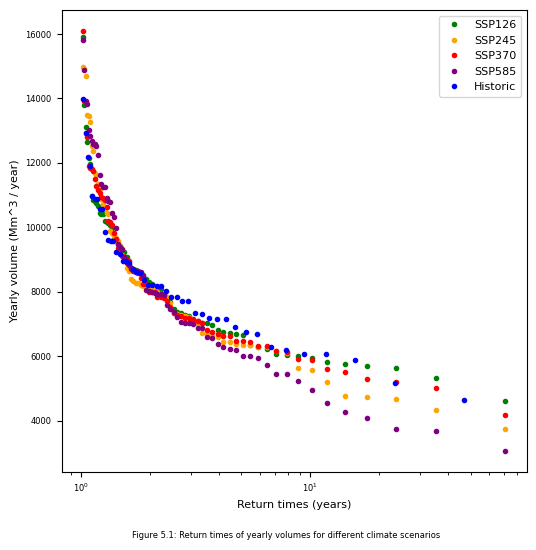

In [3]:
#Loading observed discharge data
data = pd.read_csv(Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/mohembo_daily_water_discharge_data.csv", 
                   index_col='date', parse_dates=True, dayfirst=True)
data_daily = data.resample('D').interpolate()
data_daily.columns = ['Observed discharge']
data_daily = data_daily[~data_daily.index.year.isin([1974, 2021])]

#Converting daily discharge in m^3/s to yearly volumes in Mm^3
yearly_volume = (data_daily * 3600 * 24).resample('YE').sum() / 1e6
yearly_volume.columns = ['Observed yearly volume']

#Path to SSP scenario results
path_SSP = Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data"

#Loading yearly volume data for the different scenarios
SSP126_yearly = pd.read_csv(path_SSP / 'SSP126_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP126'], header=0)
SSP245_yearly = pd.read_csv(path_SSP / 'SSP245_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP245'], header=0)
SSP370_yearly = pd.read_csv(path_SSP / 'SSP370_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP370'], header=0)
SSP585_yearly = pd.read_csv(path_SSP / 'SSP585_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP585'], header=0)

#Calculating return times
return_period_historic = return_periods(yearly_volume)
return_period_CMIP = return_periods(SSP126_yearly)

#Sorting data from low to high
historic_sorted = np.sort(yearly_volume['Observed yearly volume'])
SSP126_yearly_sorted = np.sort(SSP126_yearly['SSP126'])
SSP245_yearly_sorted = np.sort(SSP245_yearly['SSP245'])
SSP370_yearly_sorted = np.sort(SSP370_yearly['SSP370'])
SSP585_yearly_sorted = np.sort(SSP585_yearly['SSP585'])

#Plotting
fig, ax = plt.subplots(figsize=(6, 6))
plt.plot(return_period_CMIP, SSP126_yearly_sorted, marker='o', linestyle='None', ms=3, label='SSP126', color='green')
plt.plot(return_period_CMIP, SSP245_yearly_sorted, marker='o', linestyle='None', ms=3, label='SSP245', color='orange')
plt.plot(return_period_CMIP, SSP370_yearly_sorted, marker='o', linestyle='None', ms=3, label='SSP370', color='red')
plt.plot(return_period_CMIP, SSP585_yearly_sorted, marker='o', linestyle='None', ms=3, label='SSP585', color='purple')
plt.plot(return_period_historic, historic_sorted, marker='o', linestyle='None', ms=3, label='Historic', color='blue')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
ax.set_xlabel("Return times (years)", fontsize=8)
ax.set_ylabel("Yearly volume (Mm^3 / year)", fontsize=8)
plt.xscale('log')
plt.legend(fontsize=8)
fig.text(0.5, 0,"Figure 5.1: Return times of yearly volumes for different climate scenarios", ha="center", fontsize=6);

In [4]:
#Retrieving percentile for different categories
percentile15 = np.percentile(yearly_volume, 15)
percentile10 = np.percentile(yearly_volume, 10)
percentile5 = np.percentile(yearly_volume, 5)

#Calculating return times of different categories for historic data
interpolate_func_h = interp1d(historic_sorted, return_period_historic, bounds_error=False, fill_value="extrapolate")
return15_h = interpolate_func_h(percentile15)
return10_h = interpolate_func_h(percentile10)
return5_h = interpolate_func_h(percentile5)

#Calculating return times of different categories for climate scenarios
CMIP_scenarios_yearly = [SSP126_yearly_sorted, SSP245_yearly_sorted, SSP370_yearly_sorted, SSP585_yearly_sorted]
names = ['SSP126', 'SSP245', 'SSP370', 'SSP585']
for i in range(len(CMIP_scenarios_yearly)):
    interpolate_func = interp1d(CMIP_scenarios_yearly[i], return_period_CMIP, bounds_error=False, fill_value="extrapolate")
    return15 = interpolate_func(percentile15)
    return10 = interpolate_func(percentile10)
    return5 = interpolate_func(percentile5)

|                         |**Historic**     |**SSP1-2.6**      |**SSP2-4.5**       |**SSP3-7.0**      |**SSP5-8.5**      |
|-------------------------|-----------------|------------------|-------------------|------------------|------------------|
| **Q15 (6591 Mm$^3$)**   |6.08             |5.16              |3.95               |4.49              |3.55              |
| **Q10 (6135 Mm$^3$)**   |8.62             |6.87              |7.42               |7.58              |4.85              |
| **Q5 (5937 Mm$^3$)**    |14.69            |10.39             |8.22               |8.83              |5.87              |

<div align="center">
<i>Table 5.1: Return times in years</i>
</div>

## 5.2 Future hydrological droughts
For determining the number of hydrological droughts, periods of 35 years are used. The first period is from 2030 to 2064 and the second period is from 2065 to 2099. The results are then compared to the number of droughts in the last 35 years of the observed data, from 1986 to 2020. In table 5.2, the number of years in the different hydrological drought categories are shown. The first number under the climate scenario represents the first 35-year period and the second number represents the second 35 years.  The code below shows how the number of dry years in the Okavango Delta is calculated.

In [5]:
#Number of years in each drought category for last 35 years of observation
historic35 = yearly_volume[-35::]
u15_historic35 = len(historic35[(historic35['Observed yearly volume'] < percentile15) & 
                     (historic35['Observed yearly volume'] > percentile10)])
u10_historic35 = len(historic35[(historic35['Observed yearly volume'] < percentile10) & 
                     (historic35['Observed yearly volume'] > percentile5)])
u5_historic35 = len(historic35[(historic35['Observed yearly volume'] < percentile5)])

#Number of years in each drought category for climate scenarios
CMIP_scenarios = [SSP126_yearly, SSP245_yearly, SSP370_yearly, SSP585_yearly]
names = ['SSP126', 'SSP245', 'SSP370', 'SSP585']
for k in range(len(CMIP_scenarios)):
    SSP_data = CMIP_scenarios[k] 
    first35 = SSP_data[0:35]
    last35 = SSP_data[-35::]
    
    u15_first35 = len(first35[(first35[names[k]] < percentile15) & (first35[names[k]] > percentile10)])
    u15_last35 = len(last35[(last35[names[k]] < percentile15) & (last35[names[k]] > percentile10)])

    u10_first35 = len(first35[(first35[names[k]] < percentile10) & (first35[names[k]] > percentile5)])
    u10_last35 = len(last35[(last35[names[k]] < percentile10) & (last35[names[k]] > percentile5)])

    u5_first35 = len(first35[(first35[names[k]] < percentile5)])
    u5_last35 = len(last35[(last35[names[k]] < percentile5)])

|                |**Historic**     |**SSP1-2.6**      |**SSP2-4.5**       |**SSP3-7.0**      |**SSP5-8.5**      |
|----------------|-----------------|------------------|-------------------|------------------|------------------|
| **Moderate**   |1                |2 / 1             |2 / 6              |3 / 3             |4 / 2             |
| **Severe**     |2                |3 / 1             |0 / 1              |0 / 1             |0 / 2             |
| **Extreme**    |3                |3 / 3             |2 / 6              |1 / 7             |5 / 7             |
| **Total**      |6                |8 / 5             |4 / 13             |4 / 11            |9 / 11            |

<div align="center">
<i>Table 5.2: Number of dry years per category. The first number under the climate scenario represents the first 35-year (2030 – 2064) period and the second number represents the second 35 years (2065 – 2099).</i>
</div>

## 5.3 Rainfall
As mentioned in the introduction, 95% of the water flowing in the Okavango River comes from the rainfall in the Angolan catchment area (Andersson, et al., 2003). The majority of the catchment area is in Angola with 135,000 km2 compared to about 175,000 km2 for the whole catchment area. In figure 5.2, the return times of the yearly precipitation are shown for the different climate scenarios. As the HBV model output was showing bias when using historic CMIP forcing data, the precipitation is also bias corrected using quantile mapping. The quantile distribution of the ERA5 precipitation data is aligned with the historic CMIP precipitation data from. Here, it is assumed that the ERA5 precipitation data is correct. This same bias correction is used on the future precipitation of the CMIP dataset.  The code below shows how quantile mapping is used on the precipitation data and how the return times are calculated.

In [6]:
#Loading packages
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import linregress

import ewatercycle
import ewatercycle.forcing
import ewatercycle.models

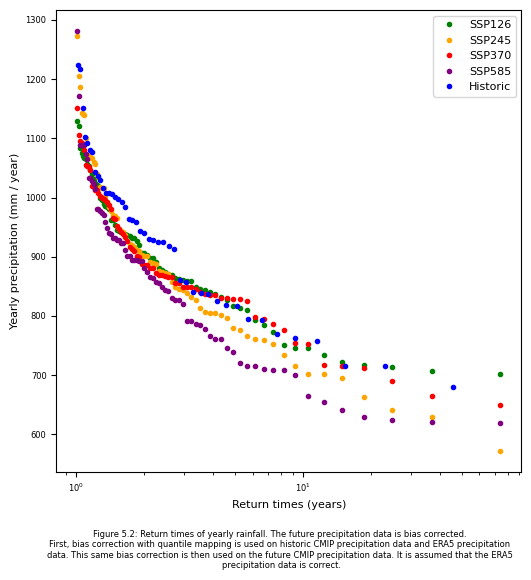

In [7]:
#Loading ERA5 data (same as used in chapter 3)
forcing_path_ERA5 = Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/ERA5_HBV/own_shapefile_3"
load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script"  
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)

#Loading CMIP data (same as used in chapter 4)
forcing_path_CMIP = Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/CMIP"  
historical_CMIP_location = forcing_path_CMIP / "historical" / "work" / "diagnostic" / "script"
historical_CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=historical_CMIP_location)

#Loading CMIP data for the different climate scenarios
forcing_path_CMIP = Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/CMIP_future"
scenarios = ['SSP126', 'SSP245', 'SSP370', 'SSP585']
names_forcing = ['SSP126_CMIP_forcing', 'SSP245_CMIP_forcing', 'SSP370_CMIP_forcing', 'SSP585_CMIP_forcing']

for scenario, name in zip(scenarios, names_forcing):
    location = forcing_path_CMIP / scenario / "work" / "diagnostic" / "script"
    globals()[name] = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(
        directory=location
    )

#Code of quantile mapping from Zoë Lucius (2025)
def quantile_mapping(observed, modelled, n):
    #Making a quantile grid 
    quantiles = np.linspace(0, 1, n)

    #Sorting data 
    observed_sorted = np.sort(observed)
    modelled_sorted = np.sort(modelled)

    #Assigning every data point to a quantile
    observed_interpolated = interp1d(np.linspace(0, 1, len(observed_sorted)), observed_sorted, bounds_error=False, fill_value="extrapolate")
    modelled_interpolated = interp1d(np.linspace(0, 1, len(modelled_sorted)), modelled_sorted, bounds_error=False, fill_value="extrapolate")

    #Aligning data points with quantile grid
    observed_on_quantiles = observed_interpolated(quantiles)
    modelled_on_quantiles = modelled_interpolated(quantiles)

    #Creating function to use on CMIP forcing data
    mapping_function = interp1d(modelled_on_quantiles, observed_on_quantiles, bounds_error=False, fill_value="extrapolate")

    return mapping_function

#Retrieving precipitation data
CMIP_historic_pr = xr.open_dataset(historical_CMIP_forcing['pr'])
CMIP_historic_pr = CMIP_historic_pr['pr'].to_series()

ERA5_pr = xr.open_dataset(ERA5_forcing['pr'])
ERA5_pr = ERA5_pr['pr'].to_series()
ERA5_pr = ERA5_pr["1970-01-01":"2014-12-31"]

forcing_data = [SSP126_CMIP_forcing, SSP245_CMIP_forcing, SSP370_CMIP_forcing, SSP585_CMIP_forcing]
names_pr = ['CMIP_pr_SSP126', 'CMIP_pr_SSP245', 'CMIP_pr_SSP370', 'CMIP_pr_SSP585']

for forcing, name in zip(forcing_data, names_pr):
    globals()[name] = xr.open_dataset(forcing['pr'])
    globals()[name] = globals()[name]['pr'].to_series()

#Using quantile with ERA5 and historic CMIP precipitation
qm_pr = quantile_mapping(ERA5_pr, CMIP_historic_pr, 1000)

#Using quantile mapping function on future CMIP precipitation
#Converting data from kg m^-2 s^-1 to mm/day and converting to yearly total
scenarios_pr_data = [CMIP_pr_SSP126, CMIP_pr_SSP245, CMIP_pr_SSP370, CMIP_pr_SSP585]
names_yearly_pr = ['SSP126_yearly_pr', 'SSP245_yearly_pr', 'SSP370_yearly_pr', 'SSP585_yearly_pr']
for pr_data, name, scenario in zip(scenarios_pr_data, names_yearly_pr, scenarios):
    corrected_pr = qm_pr(pr_data)
    df_corrected = pd.DataFrame({scenario:corrected_pr * 86400}, index=CMIP_pr_SSP126.index)
    df_yearly = df_corrected.resample('YE').sum()
    df_yearly.index = df_yearly.index.year
    globals()[name] = df_yearly

ERA5_pr = ERA5_pr * 86400
ERA5_yearly_pr = ERA5_pr.resample('YE').sum()
ERA5_yearly_pr.index = ERA5_yearly_pr.index.year

#Calculating return period
def return_periods(data):
    n = len(data)
    rank = np.arange(1, n + 1)
    return_period = (n + 1) / rank
    return return_period

#Calculating return periods
historic_return_period = return_periods(ERA5_yearly_pr)
future_return_period = return_periods(SSP126_yearly_pr)

#Sorting data
SSP126_yearly_pr_sorted = np.sort(SSP126_yearly_pr['SSP126'])
SSP245_yearly_pr_sorted = np.sort(SSP245_yearly_pr['SSP245'])
SSP370_yearly_pr_sorted = np.sort(SSP370_yearly_pr['SSP370'])
SSP585_yearly_pr_sorted = np.sort(SSP585_yearly_pr['SSP585'])
ERA5_yearly_pr_sorted = np.sort(ERA5_yearly_pr)

#Plotting
fig, ax = plt.subplots(figsize=(6, 6))
pr_sorted_data = [SSP126_yearly_pr_sorted, SSP245_yearly_pr_sorted, SSP370_yearly_pr_sorted, SSP585_yearly_pr_sorted] 
colors = ['green', 'orange', 'red', 'purple']
for sorted_data, scenario, color in zip(pr_sorted_data, scenarios, colors):
    plt.plot(future_return_period, sorted_data, marker='o',  linestyle='None', ms=3, label=scenario, color=color)
plt.plot(historic_return_period, ERA5_yearly_pr_sorted, marker='o', linestyle='None', ms=3, label='Historic', color='blue')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
ax.set_xlabel("Return times (years)", fontsize=8)
ax.set_ylabel("Yearly precipitation (mm / year)", fontsize=8)
plt.xscale('log')
plt.legend(fontsize=8)
fig.text(0.5, -0.05,"Figure 5.2: Return times of yearly rainfall. The future precipitation data is bias corrected. \n"
         "First, bias correction with quantile mapping is used on historic CMIP precipitation data and ERA5 precipitation \n"
         "data. This same bias correction is then used on the future CMIP precipitation data. It is assumed that the ERA5 \n"
         "precipitation data is correct.", ha="center", fontsize=6);

Except for climate scenario SSP1-2.6, the scenarios show lower return times of lower total yearly precipitation compared to the historical ERA5 data. The return times of the total yearly volume flowing into the Okavango Delta and the return times of the total yearly precipitation show similar form. This correlating suggest that the total yearly precipitation is an important driver of how much water flows in the Okavango River. 

Figure 5.3 shows the change in yearly precipitation versus the change in yearly volume with the fitted regression line and its R2 value. This is done by calculating the difference between the total yearly precipitation and total yearly volume between the SSP1-2.6 and SSP5-8.5 climate scenarios. Positive percentages mean that the value for the SSP5-8.5 scenario is higher than the values of the SSP1-2.6 scenario. The choice for taking the SSP1-2.6 and SSP5-8.5 precipitation is to show how the yearly volume of a particular year will react to a change in the yearly precipitation of that same year. The code is shown below.

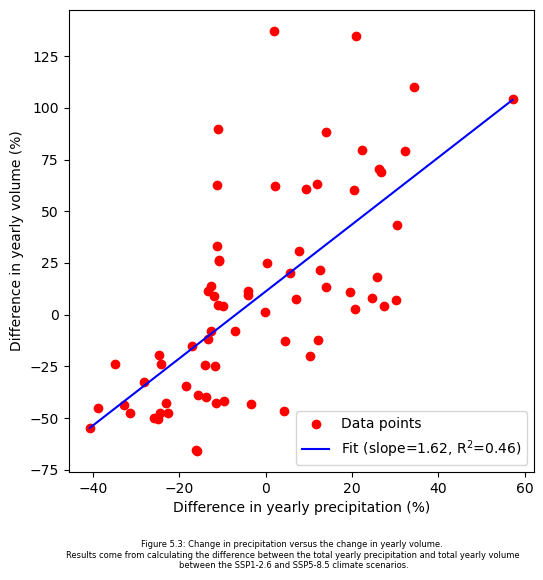

In [8]:
#Making the lengths of the yealy volume and yearly precipitation the same
#First three year in precipation have no value in yearly volume
SSP126_yearly_pr_overlap = SSP126_yearly_pr[3::]
SSP585_yearly_pr_overlap = SSP585_yearly_pr[3::]

#Calculating difference in yearly volume en yearly precipitation in percentages
delta_V_p = (SSP585_yearly['SSP585'] - SSP126_yearly['SSP126']) / SSP126_yearly['SSP126'] * 100
delta_pr_p = (SSP585_yearly_pr_overlap['SSP585'] - SSP126_yearly_pr_overlap['SSP126']) / SSP126_yearly_pr_overlap['SSP126'] * 100

#Fitting the best line through the data points and retrieving R^2 value
slope, intercept, r_value, p_value, std_err = linregress(delta_pr_p,delta_V_p)
x = np.linspace(delta_pr_p.min(), delta_pr_p.max(), 100)
y = intercept + slope * x

#Plotting
fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(delta_pr_p, delta_V_p, label='Data points', color='red')
plt.plot(x, y, label=f'Fit (slope={slope:.2f}, R$^2$={r_value**2:.2f})', color='blue')
ax.set_xlabel('Difference in yearly precipitation (%)')
ax.set_ylabel('Difference in yearly volume (%)')
plt.legend()
fig.text(0.5, -0.05,"Figure 5.3: Change in precipitation versus the change in yearly volume. \n"
         "Results come from calculating the difference between the total yearly precipitation and total yearly volume \n"
         "between the SSP1-2.6 and SSP5-8.5 climate scenarios.", ha="center", fontsize=6);

The slope of the fitted line is 1.62, suggesting that an increase of 1% in yearly precipitation is associated with an approximately increase of 1.62% in yearly volume. However, the fit of the regression line is not strong, as the  R2 value is 0.46. This suggests that that the change in yearly precipitation alone cannot fully predict the change in yearly volume. 

## 5.4 Key findings
When looking at the return times of the different hydrological drought categories, it shows that the return times get lower in the period from 2030 to 2100 which increases the frequency of such events. Except for scenario SSP1-2.6, the number of extreme droughts is projected to increase significantly in the period from 2065 to 2099 compared to the last 35 years of observation data. Also, the number of moderate droughts in the Okavango River is projected to increase in most cases. The severe droughts only got worse in the period from 2030 to 2064 in the SSP1-2.6 scenarios. The other scenarios show lower or the same number of severe droughts compared to the historical data. The climate scenarios show a worse result when looking at the moderate droughts. The total number of droughts in the period 2065 – 2099 is projected to double for the scenarios SSP2-4.5, SSP3-7.0 and SSP5-8.5, while it is projected to improve for the SSP1-2.6. It is interesting to see that the SSP2-4.5 scenario shows slightly worse results in both return times and number of droughts compared to scenario SSP3-7.0, while SSP3-7.0 is the scenario with higher CO2 emissions and more temperature rise. 

The results show that if the CO2 emissions reach net-zero by 2050 (SSP1-2.6), the situation in the Okavango Delta is projected to improve in the period 2065-2099 when looking at the total number of hydrological droughts. The results also show that the number of hydrological droughts in the delta will about double when the CO2 emissions do not reach net-zero by the end of the century. 